<a href="https://colab.research.google.com/github/robertrood-se/HCI/blob/afsana_dev/Phase_2_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv("../eda/Preprocessed_Covid19.csv", low_memory=False)

# Drop non-predictive / leakage columns
df.drop(columns=['Unnamed: 0', 'DATE_DIED', 'DEATH_MONTH',
                 'CLASIFFICATION_FINAL'], inplace=True)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}\n")


Dataset shape : (99768, 20)
Columns       : ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'INTUBED', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'DIED', 'COVID_POSITIVE']



In [3]:

TARGET   = 'COVID_POSITIVE'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Target distribution:")
print(y.value_counts(), "\n")

Target distribution:
COVID_POSITIVE
1    76693
0    23075
Name: count, dtype: int64 



In [4]:

# INTUBED & ICU: NaN = outpatient → fill with 0
X['INTUBED'].fillna(0, inplace=True)
X['ICU'].fillna(0, inplace=True)

# Remaining comorbidity NaNs (< 1%) → fill with column mode
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mode()[0], inplace=True)

assert X.isnull().sum().sum() == 0, "Still have missing values!"
print("Missing values after imputation: 0 \n")

Missing values after imputation: 0 



In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]:,}  |  Test size : {X_test.shape[0]:,}\n")


Train size : 79,814  |  Test size : 19,954



In [6]:

rf = RandomForestClassifier(
    n_estimators      = 100,
    max_depth         = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)
rf.fit(X_train, y_train)
print("Model trained \n")

Model trained 



In [7]:

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
fi   = pd.Series(rf.feature_importances_,
                 index=FEATURES).sort_values(ascending=False)

print("=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

  EVALUATION RESULTS
  Accuracy  : 0.7175
  Precision : 0.9634
  Recall    : 0.6574
  F1-Score  : 0.7815



Visualization saved as 'random_forest_covid_results.png' ✅


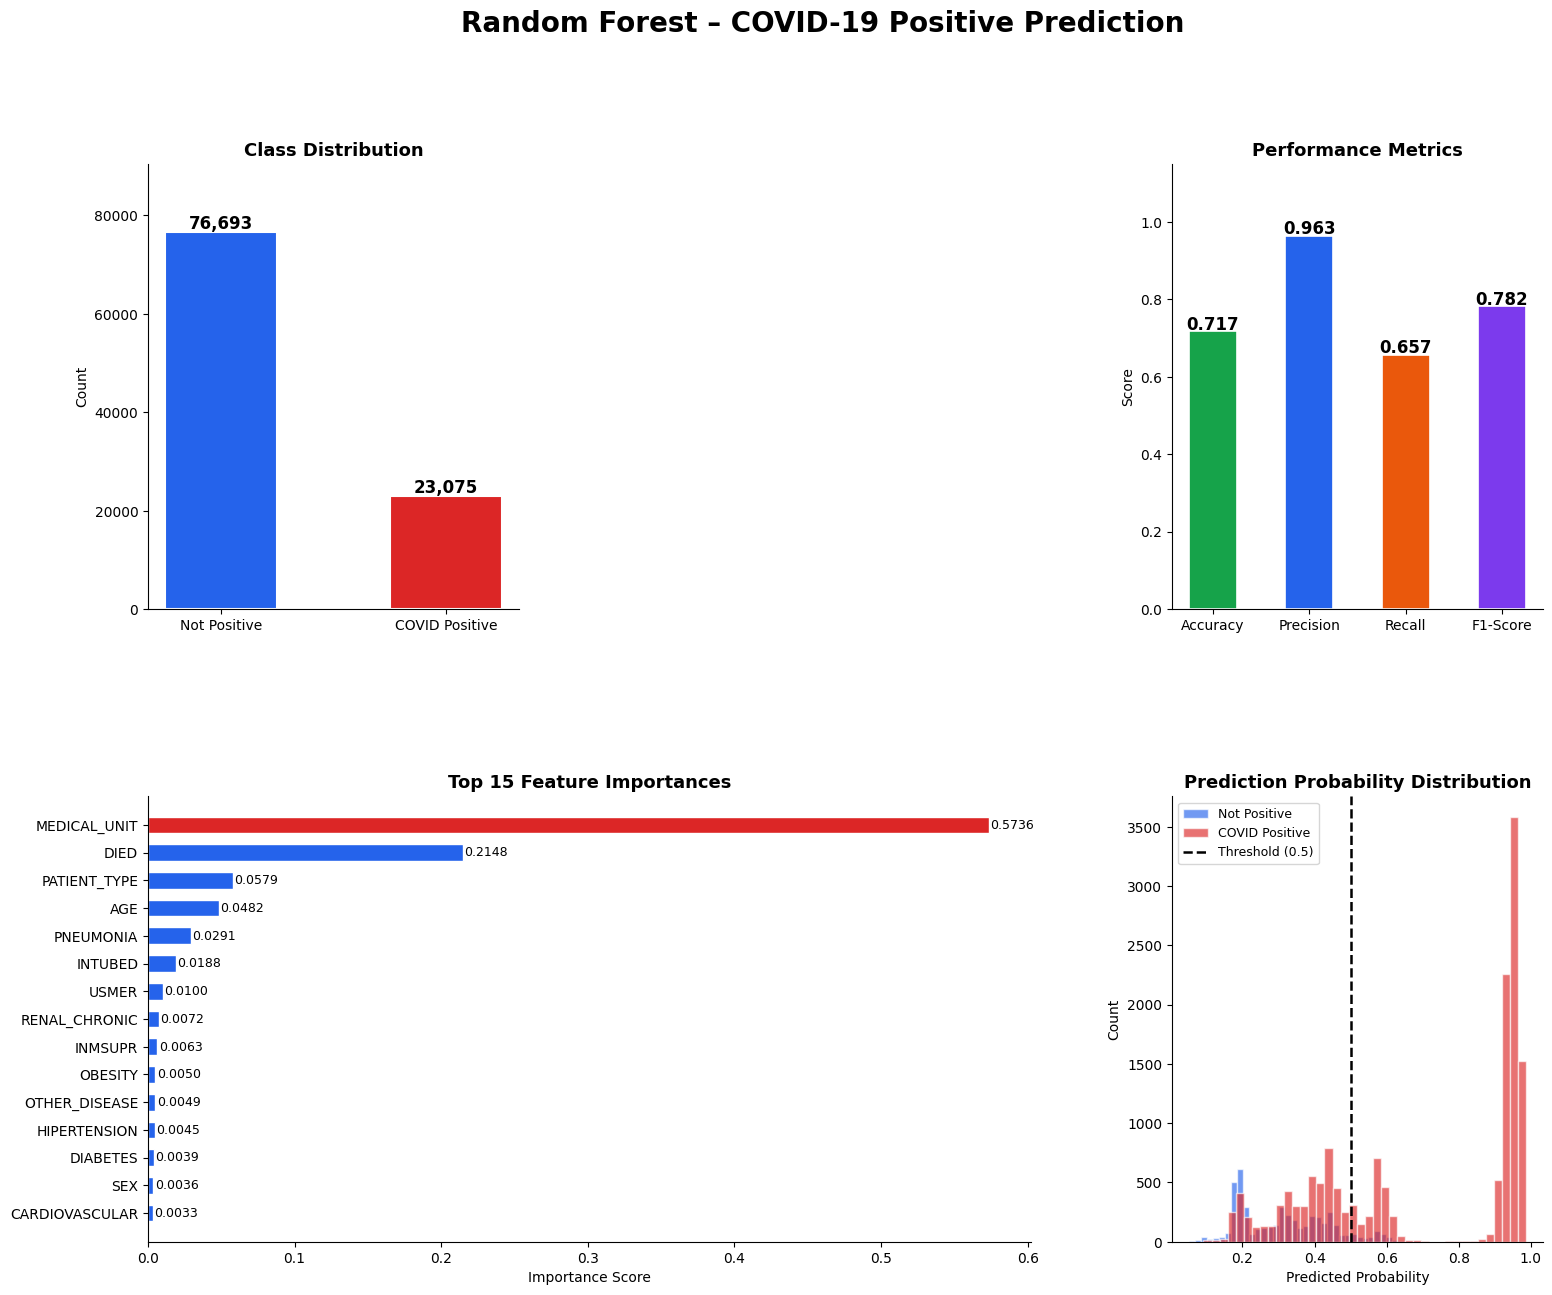

In [8]:

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white'
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Random Forest – COVID-19 Positive Prediction',
             fontsize=20, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Plot 1: Class Distribution ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars1  = ax1.bar(['Not Positive', 'COVID Positive'], counts.values,
                 color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
             f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.18)



# ── Plot 3: Performance Metrics Bar ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1
}
b3 = ax3.bar(list(metrics.keys()), list(metrics.values()),
             color=[GREEN, BLUE, ORANGE, PURPLE],
             edgecolor='white', linewidth=1.2, width=0.5)
for b in b3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')

# ── Plot 4: Top 15 Feature Importances ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top15      = fi.head(15)
bar_colors = [RED if i == 0 else BLUE for i in range(len(top15))]
bars4      = ax4.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_colors[::-1], edgecolor='white', height=0.6)
for b in bars4:
    ax4.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f'{b.get_width():.4f}', va='center', fontsize=9)
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')

# ── Plot 5: Prediction Probability Distribution ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_proba[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         label='Not Positive', edgecolor='white')
ax5.hist(y_proba[y_test == 1], bins=40, alpha=0.65, color=RED,
         label='COVID Positive', edgecolor='white')
ax5.axvline(0.5, color='black', linestyle='--', lw=1.8, label='Threshold (0.5)')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9)
ax5.set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')

plt.savefig('random_forest_covid_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("\nVisualization saved as 'random_forest_covid_results.png' ✅")